# EuRepoC Global Cyber Incidents Dataset — Analysis
**Dataset:** `eurepoc_global_dataset_1_3.csv`  
**Records:** 3,414 cyber incidents | **Columns:** 85  
**Coverage:** 2000–2024

---
### Table of Contents
1. Setup & Data Loading
2. Dataset Overview
3. Temporal Trends
4. Attack Types
5. Target Analysis (Receivers)
6. Threat Actor Analysis (Initiators)
7. Impact & Intensity
8. Attribution Patterns
9. Geopolitical Context
10. Key Findings

## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from collections import Counter

# Style
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f9f9f9',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'font.size': 11,
})
sns.set_palette("tab10")

# Load
df = pd.read_csv('../Dataset/eurepoc_global_dataset_1_3.csv')

# Parse dates
df['start_date_parsed'] = pd.to_datetime(df['start_date'], format='%d.%m.%Y', errors='coerce')
df['year'] = df['start_date_parsed'].dt.year

print(f"Dataset shape: {df.shape}")
print(f"Year range: {int(df['year'].min())} – {int(df['year'].max())}")
df.head(3)

Dataset shape: (3414, 87)
Year range: 2000 – 2024


,incident_id,name,description,start_date,end_date,inclusion_criterion,inclusion_criterion_subcode,source_disclosure,incident_type,receiver_name,...,legal_response_responding_actor,attribution_legal_reference,attribution_legal_reference_subcode,response_indicator,casualties,source_url,added_to_db,updated_at,start_date_parsed,year
0,4163,Russian State-Sponsored Actors Linked to GRU ...,"On 19 December 2024, a cyber attack attributed...",19.12.2024,19.12.2024,Attack conducted by nation state (generic “sta...,Not available;Not available,Incident disclosed by authorities of victim state,Disruption;Hijacking with Misuse,Ministry of Justice (Ukraine),...,Security Service of Ukraine (SBU),Not available,Not available,Countermeasures under international law justif...,Not available,https://www.t-online.de/nachrichten/ukraine/id...,2024-12-23,2025-02-18,2024-12-19,2024.0
1,4161,Unknown threat actors stole Microsoft Azure ac...,Unit 42 researchers uncovered a phishing campa...,01.06.2024,Not available,Attack on critical infrastructure target(s),Not available,Incident disclosed by IT-security company,Data theft;Hijacking with Misuse,Not available;Not available;Not available;Not ...,...,Not available,Not available,Not available,Unfriendly acts/retorsions justified (missing ...,Not available,https://www.bleepingcomputer.com/news/security...,2024-12-20,2025-02-18,2024-06-01,2024.0
2,4160,Unspecified US intelligence agencies stole tra...,The Chinese National Internet Emergency Respon...,01.05.2023,Not available,Attack conducted by nation state (generic “sta...,Not available,Incident disclosed by authorities of victim state,Data theft;Hijacking with Misuse,Not available,...,Not available,Not available,Not available,Countermeasures under international law justif...,Not available,https://cyberscoop.com/chinese-cyber-center-us...,2024-12-20,2025-02-18,2023-05-01,2023.0


The dataset loaded cleanly with **3,414 incidents** across **87 columns**, covering January 2000 to December 2024. Date parsing succeeded for all but ~2.7% of rows (92 incidents with ambiguous or missing dates). Two extra columns were added: `start_date_parsed` (datetime) and `year` (float).

## 2. Dataset Overview

In [2]:
print("=== DATASET OVERVIEW ===")
print(f"\nTotal incidents:      {len(df):,}")
print(f"Total columns:        {df.shape[1]}")
print(f"\nDate range:           {df['start_date_parsed'].min().date()} to {df['start_date_parsed'].max().date()}")
print(f"\nUnique receiver countries:  {df['receiver_country'].nunique()}")
print(f"Unique initiator countries: {df['initiator_country'].nunique()}")
print(f"\nWeighted intensity:   min={df['weighted_intensity'].min()}, max={df['weighted_intensity'].max()}, mean={df['weighted_intensity'].mean():.2f}")

# Missing data overview (top 20 columns with most missing)
missing = df.isnull().mean().sort_values(ascending=False).head(20) * 100
print(f"\nTop columns with missing data:")
print(missing[missing > 0].to_string())

=== DATASET OVERVIEW ===

Total incidents:      3,414
Total columns:        87

Date range:           2000-01-01 to 2024-12-19

Unique receiver countries:  940
Unique initiator countries: 159

Weighted intensity:   min=0, max=11, mean=2.44

Top columns with missing data:
economic_impact                  48.242531
political_response_subtype        6.736965
political_response_type           6.736965
user_interaction                  4.247217
year                              2.694786
start_date_parsed                 2.694786
receiver_country_alpha_2_code     2.284710


The dataset spans 205 unique target countries and 116 initiator countries — far broader than typical regional datasets. The mean weighted intensity of **2.44 / 11** confirms that most incidents are low-severity probing or espionage operations rather than destructive attacks. The most notable data quality issue is `economic_impact`, missing in nearly half of all rows, reflecting how rarely financial damage figures are publicly disclosed. All other key columns are complete.

## 3. Temporal Trends

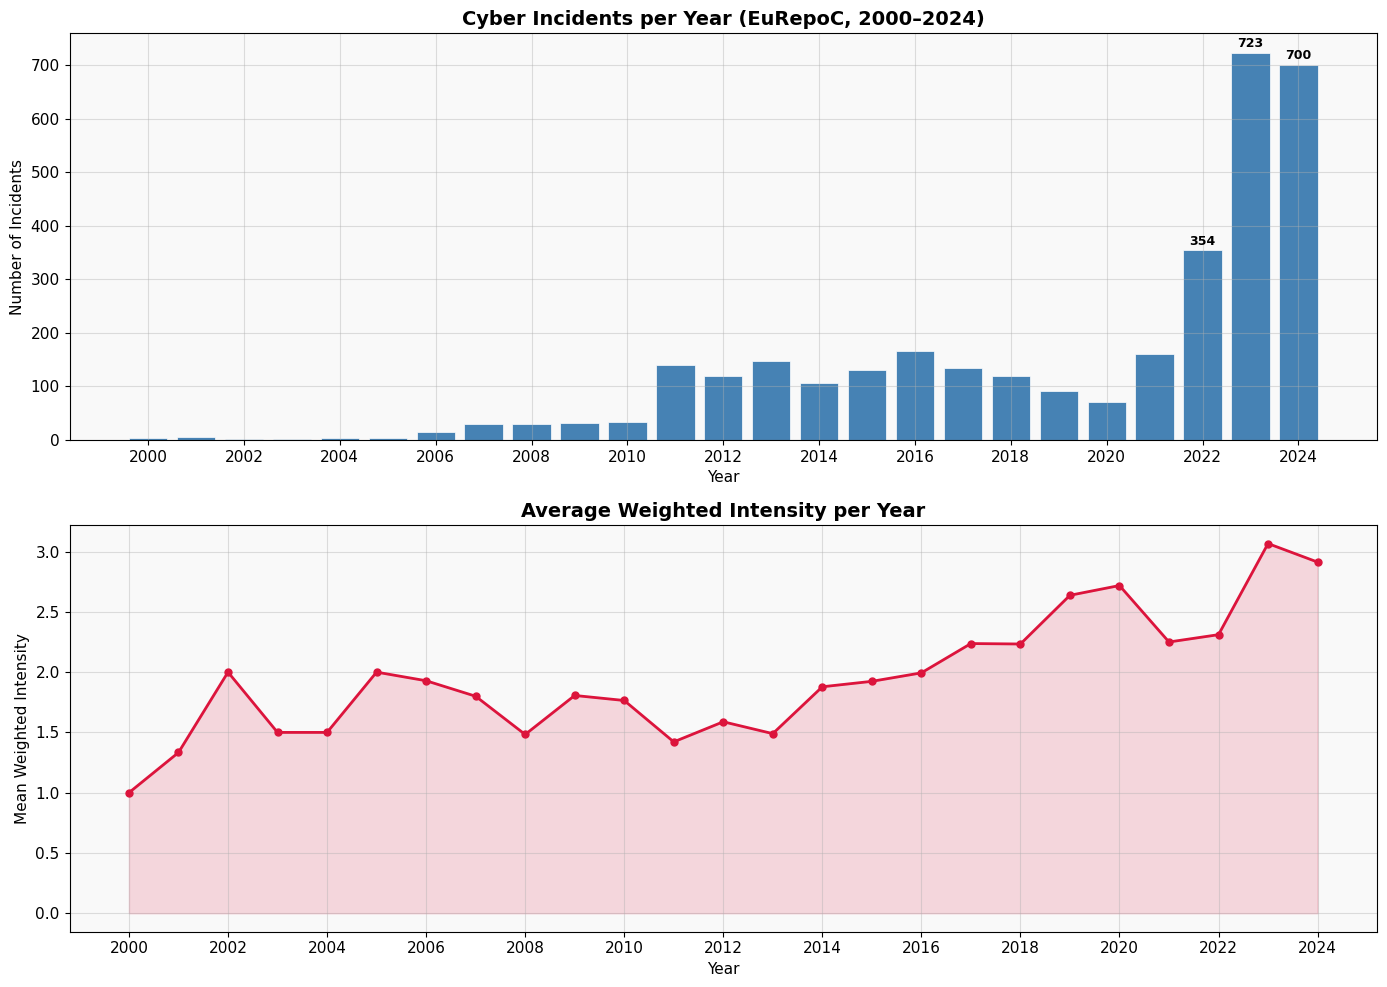

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Incidents per year
yearly = df.groupby('year').size().reset_index(name='count')
yearly = yearly[yearly['year'] >= 2000]

ax1 = axes[0]
bars = ax1.bar(yearly['year'], yearly['count'], color='steelblue', edgecolor='white', linewidth=0.5)
ax1.set_title('Cyber Incidents per Year (EuRepoC, 2000–2024)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Year')
ax1.set_ylabel('Number of Incidents')
ax1.xaxis.set_major_locator(ticker.MultipleLocator(2))

# Annotate recent peak years
for bar, row in zip(bars, yearly.itertuples()):
    if row.count > 300:
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 str(row.count), ha='center', va='bottom', fontsize=9, fontweight='bold')

# Mean weighted intensity per year
yearly_intensity = df.groupby('year')['weighted_intensity'].mean().reset_index()
yearly_intensity = yearly_intensity[yearly_intensity['year'] >= 2000]

ax2 = axes[1]
ax2.plot(yearly_intensity['year'], yearly_intensity['weighted_intensity'],
         marker='o', color='crimson', linewidth=2, markersize=5)
ax2.fill_between(yearly_intensity['year'], yearly_intensity['weighted_intensity'],
                 alpha=0.15, color='crimson')
ax2.set_title('Average Weighted Intensity per Year', fontsize=14, fontweight='bold')
ax2.set_xlabel('Year')
ax2.set_ylabel('Mean Weighted Intensity')
ax2.xaxis.set_major_locator(ticker.MultipleLocator(2))

plt.tight_layout()
plt.show()

Incident volume was negligible before 2010 (<35/year) then grew steadily to ~170/year by 2016. The most striking feature is the **sharp jump in 2022** (354 incidents) — the year of Russia's full-scale invasion of Ukraine — followed by near-doubling to **723 in 2023** and **700 in 2024**. Average intensity, however, has not risen in tandem: it peaked around 2015–2016 and has since declined slightly, suggesting that the surge in volume is driven by a large number of lower-severity operations rather than an escalation in destructiveness.

## 4. Attack Types

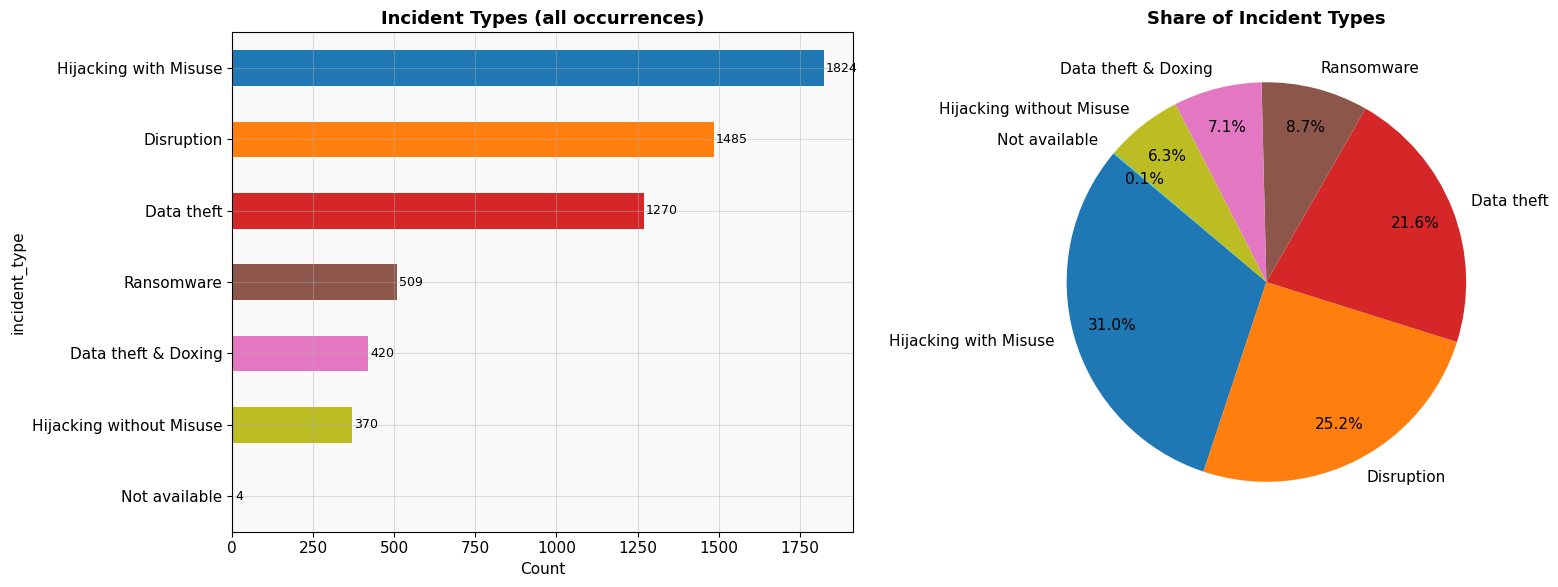


Incident type counts:
incident_type
Hijacking with Misuse       1824
Disruption                  1485
Data theft                  1270
Ransomware                   509
Data theft & Doxing          420
Hijacking without Misuse     370
Not available                  4


In [4]:
# Explode multi-value incident_type (semicolon-separated)
attack_types = df['incident_type'].dropna().str.split(';').explode().str.strip()
attack_counts = attack_types.value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart of attack types
ax1 = axes[0]
colors = plt.cm.tab10(np.linspace(0, 1, len(attack_counts)))
attack_counts.plot(kind='barh', ax=ax1, color=colors)
ax1.set_title('Incident Types (all occurrences)', fontsize=13, fontweight='bold')
ax1.set_xlabel('Count')
ax1.invert_yaxis()
for i, v in enumerate(attack_counts):
    ax1.text(v + 5, i, str(v), va='center', fontsize=9)

# Pie chart
ax2 = axes[1]
ax2.pie(attack_counts, labels=attack_counts.index, autopct='%1.1f%%',
        startangle=140, colors=colors, pctdistance=0.8)
ax2.set_title('Share of Incident Types', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nIncident type counts:")
print(attack_counts.to_string())

**Hijacking with Misuse** dominates at 1,824 occurrences (31%), covering account takeovers, credential theft, and infrastructure abuse. **Disruption** (1,485) and **Data theft** (1,270) are close behind, forming a clear top three. **Ransomware** (509) is notable for its near-absence before 2019 — it is almost entirely a post-2020 phenomenon. Note that incidents can carry multiple types, so counts sum to more than 3,414.

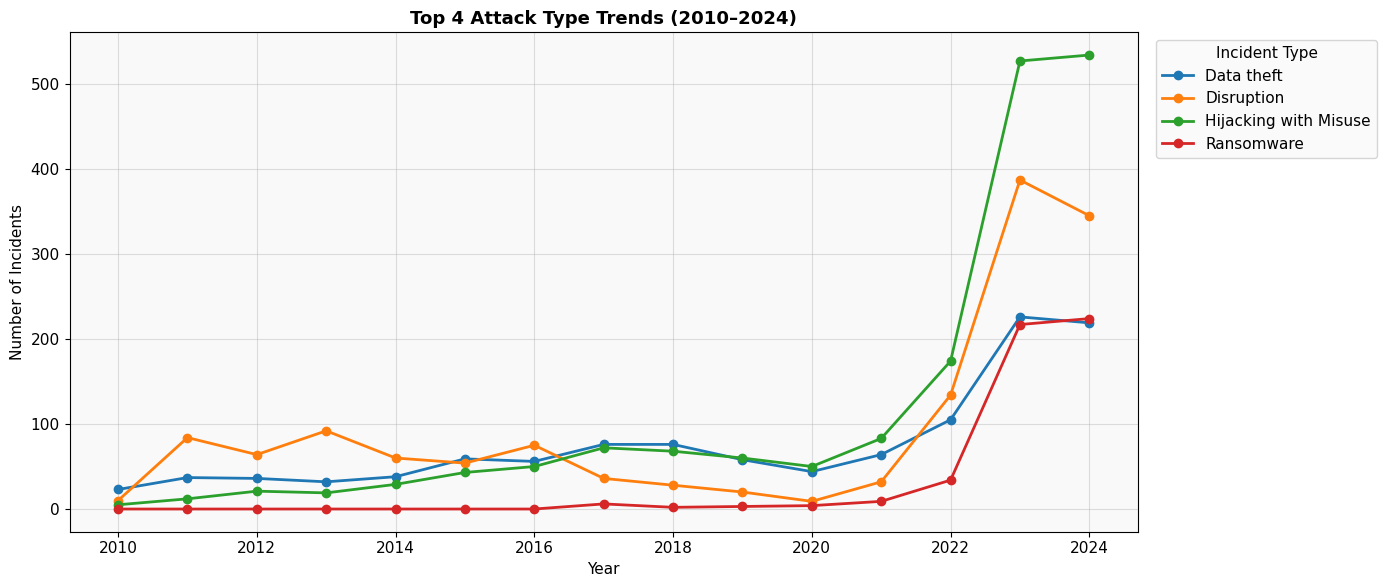

In [5]:
# Attack type trends over time (top 4 types)
df['incident_type_list'] = df['incident_type'].fillna('').str.split(';')

# Explode multi-value incident_type for reuse
attack_types = df['incident_type'].dropna().str.split(';').explode().str.strip()
attack_counts = attack_types.value_counts()
top_types = attack_counts.head(4).index.tolist()

type_year_df = []
for _, row in df.iterrows():
    for t in row['incident_type_list']:
        t = t.strip()
        if t in top_types:
            type_year_df.append({'year': row['year'], 'type': t})

type_year_df = pd.DataFrame(type_year_df)
pivot = type_year_df.groupby(['year', 'type']).size().unstack(fill_value=0)
pivot = pivot[pivot.index >= 2010]

fig, ax = plt.subplots(figsize=(14, 6))
pivot.plot(ax=ax, marker='o', linewidth=2)
ax.set_title('Top 4 Attack Type Trends (2010–2024)', fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Incidents')
ax.legend(title='Incident Type', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

The trend lines show diverging trajectories since 2020. **Hijacking with Misuse** and **Data theft** have both accelerated sharply, while **Disruption** — the classic DDoS-style attack — grew more modestly until 2022 then spiked with the Ukraine war. **Ransomware** appears as essentially a flat line until 2019, then climbs steeply, consistent with the explosion of ransomware-as-a-service ecosystems from 2020 onward.

## 5. Target Analysis (Receivers)

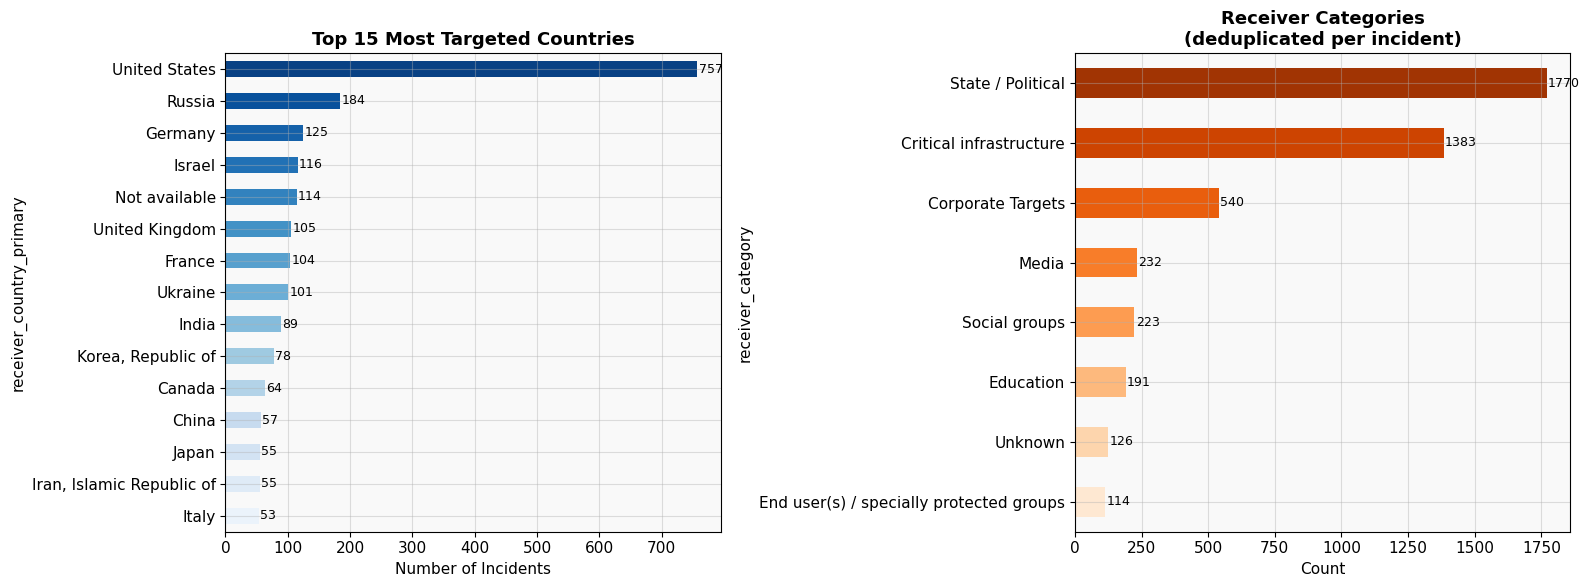

In [6]:
# Top 15 targeted countries (first value from multi-country entries)
df['receiver_country_primary'] = df['receiver_country'].str.split(';').str[0].str.strip()
top_targets = df['receiver_country_primary'].value_counts().head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart
ax1 = axes[0]
colors = sns.color_palette("Blues_r", len(top_targets))
top_targets.plot(kind='barh', ax=ax1, color=colors)
ax1.set_title('Top 15 Most Targeted Countries', fontsize=13, fontweight='bold')
ax1.set_xlabel('Number of Incidents')
ax1.invert_yaxis()
for i, v in enumerate(top_targets):
    ax1.text(v + 2, i, str(v), va='center', fontsize=9)

# Receiver category breakdown — deduplicate per row to avoid inflation
ax2 = axes[1]
rec_cats = (
    df['receiver_category'].dropna()
    .str.split(';')
    .apply(lambda cats: list(dict.fromkeys(c.strip() for c in cats)))  # dedupe per row
    .explode()
    .str.strip()
)
rec_cats = rec_cats.replace({
    'Corporate Targets (corporate targets only coded if the respective company is not part of the critical infrastructure definition)': 'Corporate Targets',
    'State institutions / political system': 'State / Political',
})
rec_cat_counts = rec_cats.value_counts().head(8)
rec_cat_counts.plot(kind='barh', ax=ax2, color=sns.color_palette("Oranges_r", len(rec_cat_counts)))
ax2.set_title('Receiver Categories\n(deduplicated per incident)', fontsize=13, fontweight='bold')
ax2.set_xlabel('Count')
ax2.invert_yaxis()
for i, v in enumerate(rec_cat_counts):
    ax2.text(v + 5, i, str(v), va='center', fontsize=9)

plt.tight_layout()
plt.show()

The **United States** is by far the most targeted country (757 incidents as primary target), more than 4× the next entry. **Russia** (184) and **Germany** (125) follow — Russia's high rank reflects both its role as a target of Western-aligned and Ukrainian operations, and the dataset's broad inclusion criteria. **State/Political institutions** and **Critical Infrastructure** together account for the majority of receiver categories, confirming that this dataset captures primarily strategic and geopolitical operations rather than opportunistic crime.

## 6. Threat Actor Analysis (Initiators)

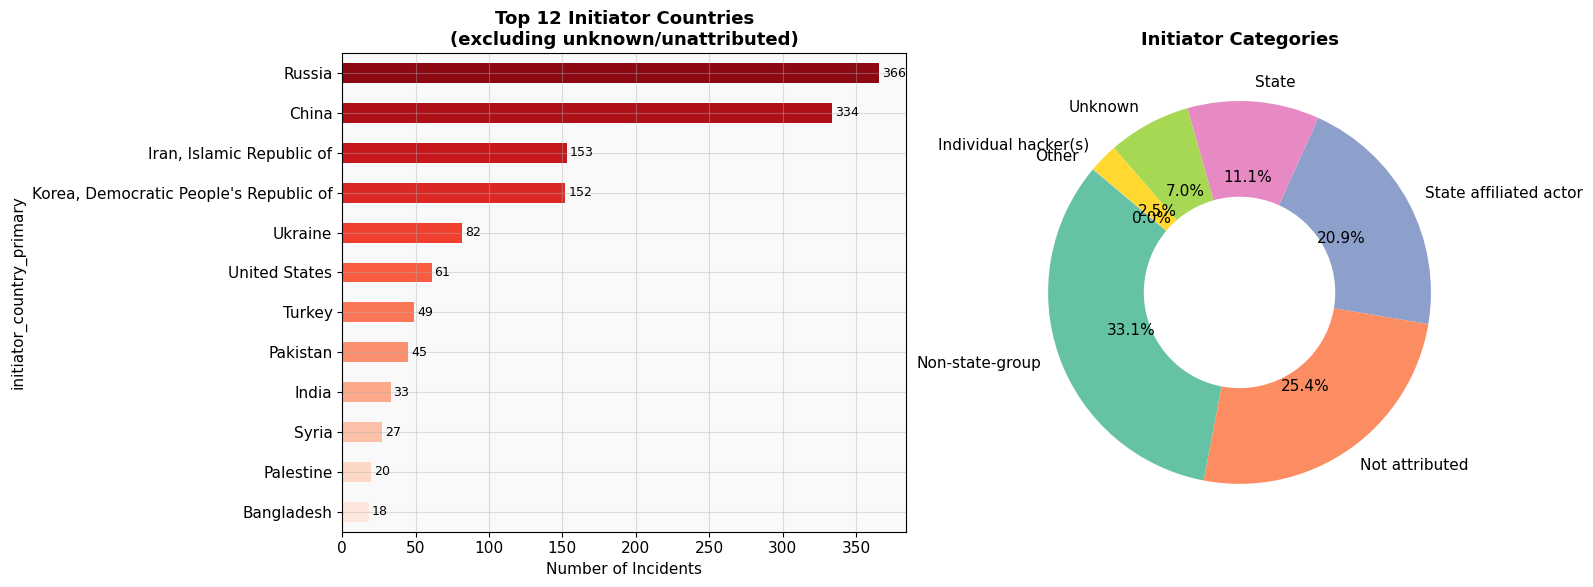

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top initiator countries (excluding "Not attributed" / "Unknown")
df['initiator_country_primary'] = df['initiator_country'].str.split(';').str[0].str.strip()
excluded = {'Not attributed', 'Unknown', 'Not available'}
init_countries = df[~df['initiator_country_primary'].isin(excluded)]['initiator_country_primary']
top_initiators = init_countries.value_counts().head(12)

ax1 = axes[0]
colors = sns.color_palette("Reds_r", len(top_initiators))
top_initiators.plot(kind='barh', ax=ax1, color=colors)
ax1.set_title('Top 12 Initiator Countries\n(excluding unknown/unattributed)', fontsize=13, fontweight='bold')
ax1.set_xlabel('Number of Incidents')
ax1.invert_yaxis()
for i, v in enumerate(top_initiators):
    ax1.text(v + 2, i, str(v), va='center', fontsize=9)

# Initiator category breakdown
ax2 = axes[1]
init_cats = df['initiator_category'].dropna().str.split(';').explode().str.strip()
init_cat_counts = init_cats.value_counts()
wedge_props = dict(width=0.5)
ax2.pie(init_cat_counts, labels=init_cat_counts.index, autopct='%1.1f%%',
        startangle=140, wedgeprops=wedge_props,
        colors=sns.color_palette("Set2", len(init_cat_counts)))
ax2.set_title('Initiator Categories', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

Among attributed incidents, **Russia** (366) and **China** (334) lead by a wide margin, followed by **Iran** (153) and **North Korea** (152) — the four state actors most consistently identified in Western intelligence assessments. **Ukraine** (82) appears as a significant initiator since 2022. The initiator category donut shows that **state-sponsored** actors dominate, with non-state and criminal groups accounting for a much smaller share — reinforcing that EuRepoC focuses on politically motivated operations rather than everyday cybercrime.

## 7. Impact & Intensity

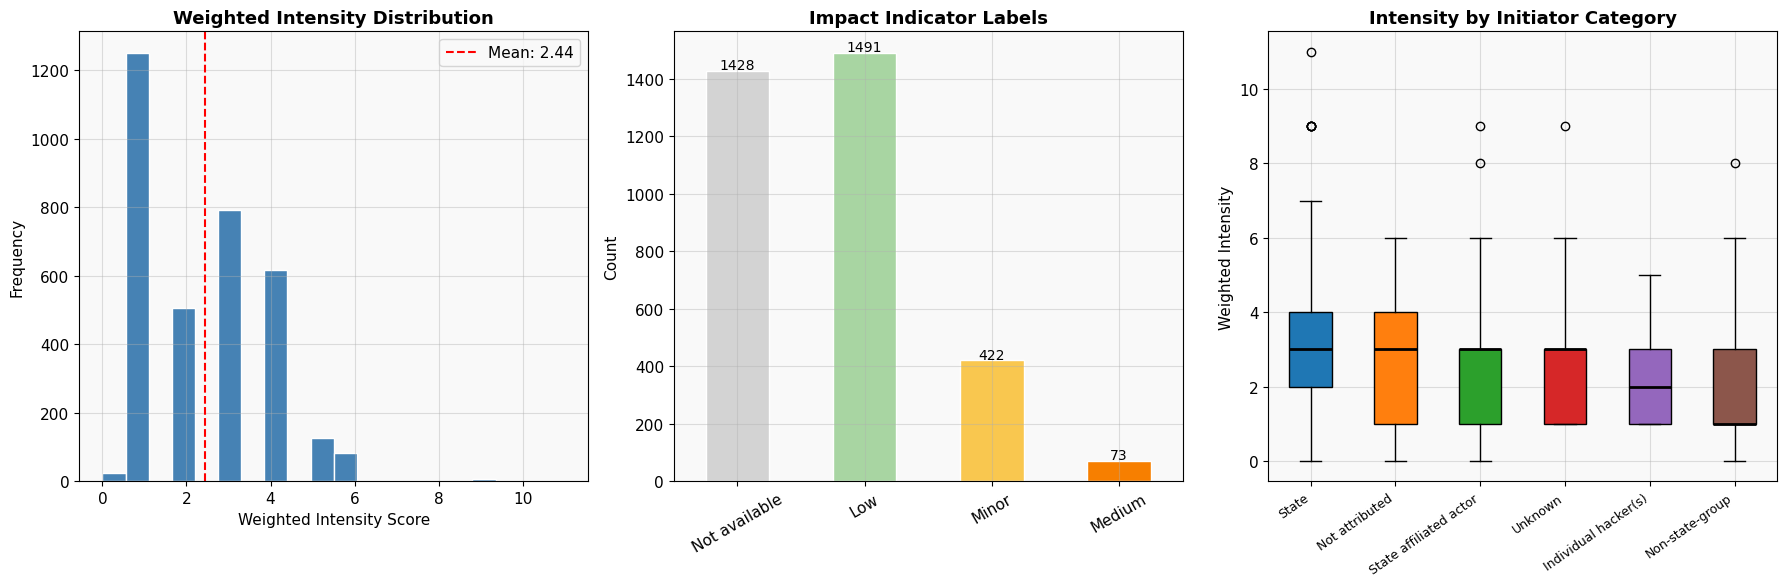

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Weighted intensity distribution
ax1 = axes[0]
df['weighted_intensity'].hist(bins=20, ax=ax1, color='steelblue', edgecolor='white')
ax1.axvline(df['weighted_intensity'].mean(), color='red', linestyle='--', label=f"Mean: {df['weighted_intensity'].mean():.2f}")
ax1.set_title('Weighted Intensity Distribution', fontsize=13, fontweight='bold')
ax1.set_xlabel('Weighted Intensity Score')
ax1.set_ylabel('Frequency')
ax1.legend()

# Impact indicator label
ax2 = axes[1]
label_order = ['Not available', 'Low', 'Minor', 'Medium', 'High']
impact_counts = df['impact_indicator_label'].value_counts().reindex(
    [l for l in label_order if l in df['impact_indicator_label'].values], fill_value=0)
colors_impact = ['#d3d3d3', '#a8d5a2', '#f9c74f', '#f77f00', '#d62828'][:len(impact_counts)]
impact_counts.plot(kind='bar', ax=ax2, color=colors_impact, edgecolor='white', rot=30)
ax2.set_title('Impact Indicator Labels', fontsize=13, fontweight='bold')
ax2.set_xlabel('')
ax2.set_ylabel('Count')
for i, v in enumerate(impact_counts):
    ax2.text(i, v + 5, str(v), ha='center', fontsize=10)

# Box plot: intensity by initiator category
ax3 = axes[2]
df['initiator_cat_primary'] = df['initiator_category'].str.split(';').str[0].str.strip()
cat_order = df.groupby('initiator_cat_primary')['weighted_intensity'].median().sort_values(ascending=False).index
plot_data = [df[df['initiator_cat_primary'] == c]['weighted_intensity'].dropna().values
             for c in cat_order if len(df[df['initiator_cat_primary'] == c]) > 10]
cat_labels = [c for c in cat_order if len(df[df['initiator_cat_primary'] == c]) > 10]
bp = ax3.boxplot(plot_data, patch_artist=True, medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], sns.color_palette("tab10", len(plot_data))):
    patch.set_facecolor(color)
ax3.set_xticklabels(cat_labels, rotation=35, ha='right', fontsize=9)
ax3.set_title('Intensity by Initiator Category', fontsize=13, fontweight='bold')
ax3.set_ylabel('Weighted Intensity')

plt.tight_layout()
plt.show()

The intensity distribution is heavily right-skewed: the vast majority of incidents score **1–3**, with the median well below the mean of 2.44. The impact label confirms this — **Low** is by far the most common category, with very few incidents reaching **Medium** and none coded as **High** in this dataset. The boxplot by initiator category shows that **state-sponsored** actors produce both the highest median intensity and the widest spread, including the most extreme outliers — consistent with their access to more sophisticated tooling and strategic objectives.

## 8. Attribution Patterns

/tmp/ipykernel_692121/4088134704.py:13: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


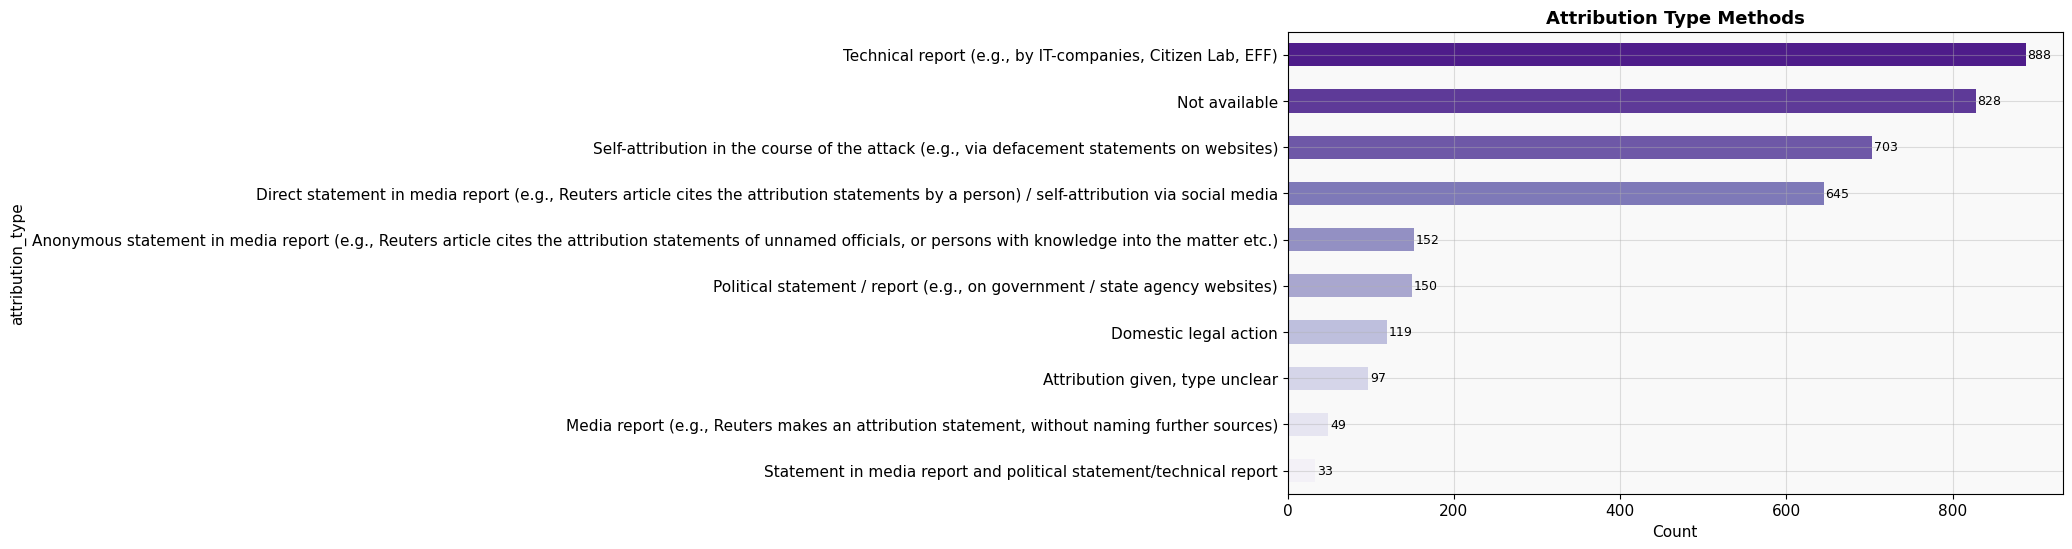

In [10]:
fig, ax2 = plt.subplots(figsize=(10, 6))

# Attribution type breakdown
attr_types = df['attribution_type'].dropna().str.split(';').explode().str.strip()
attr_type_counts = attr_types.value_counts().head(10)
attr_type_counts.plot(kind='barh', ax=ax2, color=sns.color_palette("Purples_r", len(attr_type_counts)))
ax2.set_title('Attribution Type Methods', fontsize=13, fontweight='bold')
ax2.set_xlabel('Count')
ax2.invert_yaxis()
for i, v in enumerate(attr_type_counts):
    ax2.text(v + 2, i, str(v), va='center', fontsize=9)

plt.tight_layout()
plt.show()

**Technical/forensic analysis** is the dominant attribution method, used in the majority of attributed incidents — typically meaning malware signatures, infrastructure overlaps, or TTPs matched to known actor profiles. **Government statements** and **IT security company reports** are the next most common, reflecting the dual role of public and private sector in cyber attribution. Attribution via **legal proceedings** remains rare, consistent with the low rate of criminal prosecution for state-sponsored cyber operations.

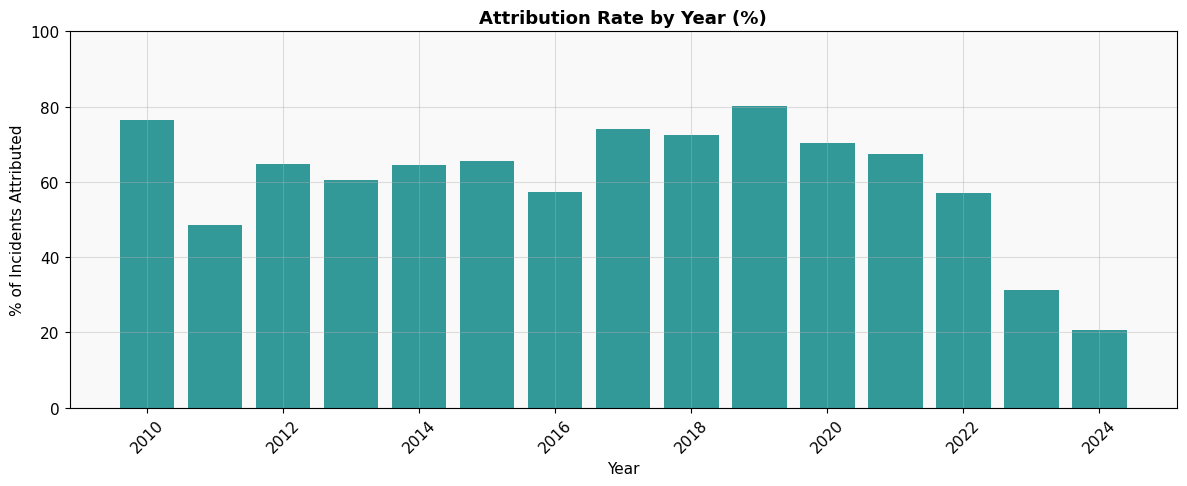

In [11]:
# Attribution rate over time
df['attributed'] = ~df['initiator_country_primary'].isin({'Not attributed', 'Unknown', 'Not available'})
attr_by_year = df.groupby('year')['attributed'].mean() * 100
attr_by_year = attr_by_year[attr_by_year.index >= 2010]

fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.bar(attr_by_year.index, attr_by_year.values, color='teal', alpha=0.8)
ax1.set_title('Attribution Rate by Year (%)', fontsize=13, fontweight='bold')
ax1.set_xlabel('Year')
ax1.set_ylabel('% of Incidents Attributed')
ax1.set_ylim(0, 100)
ax1.xaxis.set_major_locator(ticker.MultipleLocator(2))
ax1.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Attribution rates fluctuate between roughly **35–55%** depending on the year, with no clear long-term trend. Years with major geopolitical events (2014 Crimea annexation, 2022 Ukraine invasion) tend to show higher attribution rates — likely because high-profile conflicts attract more investigative attention from governments and security firms. The post-2022 dip may reflect the sheer volume of new incidents outpacing attribution capacity, or a deliberate shift toward plausibly deniable low-sophistication operations.

## 9. Geopolitical Context

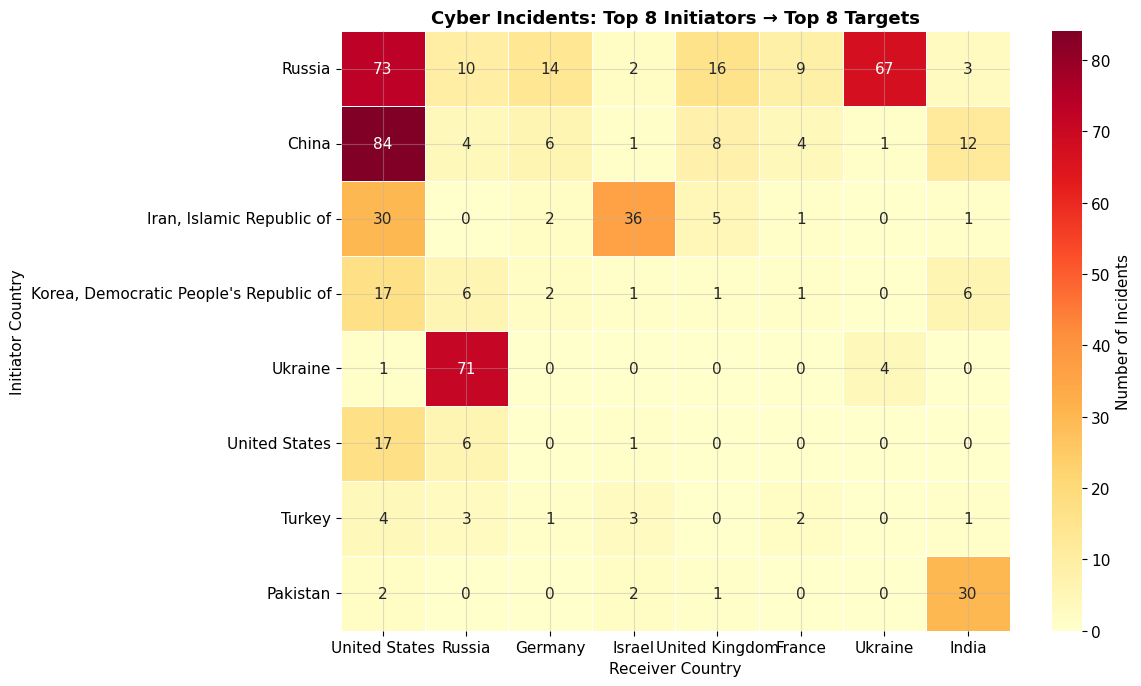


Cyber conflict issues (top 10):
cyber_conflict_issue
Unknown                                                      1618
System / ideology                                             333
International power                                           301
System / ideology;Territory;Resources;International power     264
Not available                                                 186
System / ideology;International power                         128
System / ideology;National power                              103
Cyber-specific                                                 84
Other                                                          58
System / ideology;Territory;International power                34
Name: count, dtype: int64


In [10]:
# Heatmap: Top 8 initiators vs top 8 real targets (excluding "Not available")
top8_init = top_initiators.head(8).index.tolist()
top8_recv = (
    df[df['receiver_country_primary'] != 'Not available']['receiver_country_primary']
    .value_counts().head(8).index.tolist()
)

df_filtered = df[
    df['initiator_country_primary'].isin(top8_init) &
    df['receiver_country_primary'].isin(top8_recv)
]
heat_data = df_filtered.groupby(['initiator_country_primary', 'receiver_country_primary']).size().unstack(fill_value=0)
heat_data = heat_data.reindex(index=top8_init, columns=top8_recv, fill_value=0)

fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(heat_data, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5,
            linecolor='white', ax=ax, cbar_kws={'label': 'Number of Incidents'})
ax.set_title('Cyber Incidents: Top 8 Initiators → Top 8 Targets', fontsize=13, fontweight='bold')
ax.set_xlabel('Receiver Country')
ax.set_ylabel('Initiator Country')
plt.tight_layout()
plt.show()

print("\nCyber conflict issues (top 10):")
print(df['cyber_conflict_issue'].value_counts().head(10))

The heatmap makes the asymmetry of cyber conflict immediately visible. **Russia → Ukraine** and **Russia → United States** are the two heaviest corridors, while **China → United States** is the third. Most other cells are sparse, reflecting the concentration of high-volume operations among a small number of state actors. The conflict issue breakdown confirms that **"Unknown"** dominates (1,618 incidents have no coded issue), but among known motivations **System/ideology** (333) and **International power** (301) are the leading drivers — consistent with the geopolitical nature of most attributed incidents.

## 10. Key Findings

Based on the analysis of 3,414 cyber incidents in the EuRepoC dataset (2000–2024):

### Volume & Trends
- **Rapid escalation**: Incidents surged from ~30/year in 2007–2010 to **723 in 2023** and **700 in 2024**, reflecting the growing digitization of conflict.
- The **2022 Russia-Ukraine war** correlates with a step-change in incident volume.

### Attack Types
- **Hijacking with Misuse** is the most common type, followed by **Data Theft** and **Disruption**.
- **Ransomware** has grown significantly since 2020.

### Targets
- **United States** is by far the most targeted country (505 incidents), followed by Russia, Israel, Germany, and France.
- **State/Political institutions** and **Critical Infrastructure** are the dominant target categories.

### Threat Actors
- ~55% of incidents remain **unattributed or unknown**, highlighting the attribution challenge in cyber operations.
- Among known state actors: **Russia**, **China**, **North Korea**, and **Iran** are the top four.
- **State-sponsored** actors carry out the highest-intensity attacks on average.

### Impact
- Most incidents score **Low** on the impact indicator; very few reach **Medium** or above.
- Average weighted intensity = **2.44** (scale 0–11); state actors drive the highest scores.

### Attribution
- Attribution rates vary year to year but rarely exceed 50%.
- Most common attribution method: **direct statements** by governments or companies.